In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import torch
import os

In [2]:
from matplotlib import font_manager

font_dirs = ['/home/shenm19/arial-font/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'

In [3]:
df1 = pd.read_csv('experiment_metrics_fully_parallel/param-400M.csv')

print(df1.columns)

Index(['equiv/t=0.95/mean_pred_error', 'train_loss_epoch',
       'equiv/t=0/pct_loss_from_equiv_error', 'equiv/t=0.99/total_mse',
       'train/loss_epoch', 'equiv/t=0.95/total_mse',
       'train/distogram_loss_epoch', 'equiv/t=0.8/mean_pred_error',
       'validation_loss/distogram_loss_step', 'epoch',
       'validation_loss/dist_mat_loss_step', 'train_info/epoch_duration_secs',
       'equiv/t=0.99/mean_pred_error', 'equiv/t=0.9/total_mse',
       'validation_loss/distogram_loss_epoch', 'train/trans_loss_epoch',
       'train/distogram_loss_step', 'validation_loss/auxiliary_loss_step',
       'scaling/nsamples_processed', 'train_loss_step',
       'validation_loss/dist_mat_loss_epoch', 'equiv/t=0/mean_pred_error',
       'validation_loss/loss_step', 'train/loss_step',
       'equiv/t=0.8/pct_loss_from_equiv_error', 'equiv/t=0/total_mse',
       'equiv/t=0.99/pct_loss_from_equiv_error', '_runtime',
       'equiv/t=0.4/mean_pred_error', 'equiv/t=0.95/pct_loss_from_equiv_error',
    

In [4]:
cols = ['_step'] + [col for col in df1.columns if col.startswith('equiv/t=') and col.endswith('pct_loss_from_equiv_error')]
print(cols)

df1[cols].dropna().reset_index(drop=True).set_index('_step')

['_step', 'equiv/t=0/pct_loss_from_equiv_error', 'equiv/t=0.8/pct_loss_from_equiv_error', 'equiv/t=0.99/pct_loss_from_equiv_error', 'equiv/t=0.95/pct_loss_from_equiv_error', 'equiv/t=0.6/pct_loss_from_equiv_error', 'equiv/t=0.4/pct_loss_from_equiv_error', 'equiv/t=0.2/pct_loss_from_equiv_error', 'equiv/t=0.9/pct_loss_from_equiv_error']


,equiv/t=0/pct_loss_from_equiv_error,equiv/t=0.8/pct_loss_from_equiv_error,equiv/t=0.99/pct_loss_from_equiv_error,equiv/t=0.95/pct_loss_from_equiv_error,equiv/t=0.6/pct_loss_from_equiv_error,equiv/t=0.4/pct_loss_from_equiv_error,equiv/t=0.2/pct_loss_from_equiv_error,equiv/t=0.9/pct_loss_from_equiv_error
_step,,,,,,,,
140,0.060411,0.081283,0.090258,0.089417,0.075082,0.068996,0.064894,0.084461
281,0.059774,0.072808,0.077374,0.075378,0.067380,0.064075,0.063942,0.073745
422,0.040770,0.040563,0.050549,0.049386,0.040777,0.042670,0.041957,0.044376
563,0.033150,0.029548,0.033090,0.030027,0.031365,0.031951,0.032792,0.031689
704,0.023641,0.024067,0.023360,0.024452,0.023535,0.024014,0.024684,0.024590
...,...,...,...,...,...,...,...,...
122686,0.000573,0.031083,0.021543,0.027939,0.008956,0.006450,0.000572,0.047447
122827,0.000535,0.027382,0.020748,0.028477,0.017887,0.003963,0.001568,0.049686
122968,0.000432,0.049403,0.027478,0.044147,0.035332,0.006958,0.001683,0.061572


In [23]:
def variable_span_ema(data: pd.Series, span_scale_factor: int = 1000) -> pd.Series:
    """
    Calculates an EMA with a span that increases with the index value (timestep).

    Args:
        data (pd.Series): The input data to smooth. Must have a numeric index (e.g., timesteps).
        span_scale_factor (int): Controls how quickly the span grows. A larger value
                                 means the span grows slower, resulting in less smoothing.
                                 The span at a given timestep `x` is roughly `x / span_scale_factor`.

    Returns:
        pd.Series: The smoothed data with the same index as the input.
    """
    if data.empty:
        return data

    # Get index and values for faster iteration
    index = data.index.to_numpy()
    values = data.to_numpy()
    
    # Initialize the output array and the first EMA value
    ema_values = np.zeros_like(values)
    ema_values[0] = values[0] 

    # Iterate from the second point onwards
    for i in range(1, len(values)):
        current_step = index[i]
        
        # 1. Calculate the variable span. Ensure it's at least 1.
        span = max(1.0, current_step / span_scale_factor)
        
        # 2. Convert span to alpha
        alpha = 2.0 / (span + 1.0)
        
        # 3. Apply the EMA formula
        ema_values[i] = alpha * values[i] + (1 - alpha) * ema_values[i-1]
        
    return pd.Series(ema_values, index=data.index)


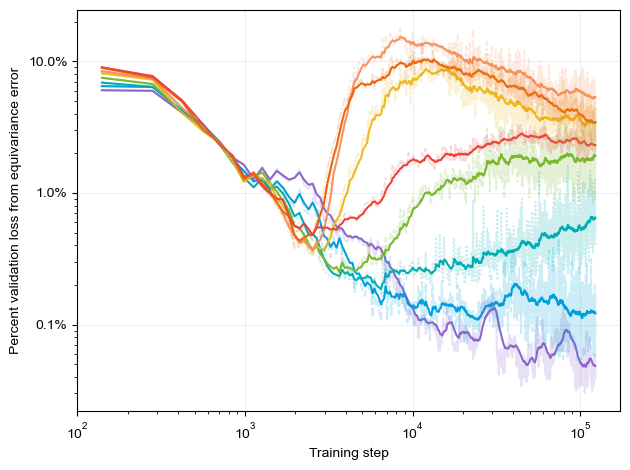

In [25]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

cols = ['_step'] + [col for col in df1.columns if col.startswith('equiv/t=') and col.endswith('pct_loss_from_equiv_error')]
plot_df = df1[cols].dropna().reset_index(drop=True).set_index('_step')

plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/pct_loss_from_equiv_error', ''))

plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['_step'], var_name = 'time', value_name = 'pct_loss_from_equiv_error')

fig, ax = plt.subplots()
sns.lineplot(
    data = melted_smoothed_plot_df,
    x = '_step',
    y = 'pct_loss_from_equiv_error',
    hue = 'time',
    errorbar = None,
    palette=color_palette,
    linestyle='-',
    alpha=1.0,
    legend = False,
    ax=ax,
)
sns.lineplot(
    data = plot_df,
    errorbar = None,
    palette=color_palette,
    alpha=0.2,
    legend=False,
    ax=ax,
)

plt.yscale('log')
plt.xscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha = 0.2)

plt.xlabel(f'Training step');
plt.ylabel(f'Percent validation loss from equivariance error');

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# plt.savefig('prot_400M.png', bbox_inches='tight', dpi=300)
# plt.show()
# plt.close()

plot_name = f"prot_400M"

import os
os.makedirs('pdfs', exist_ok=True)

plt.tight_layout()
plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.show()
plt.close()

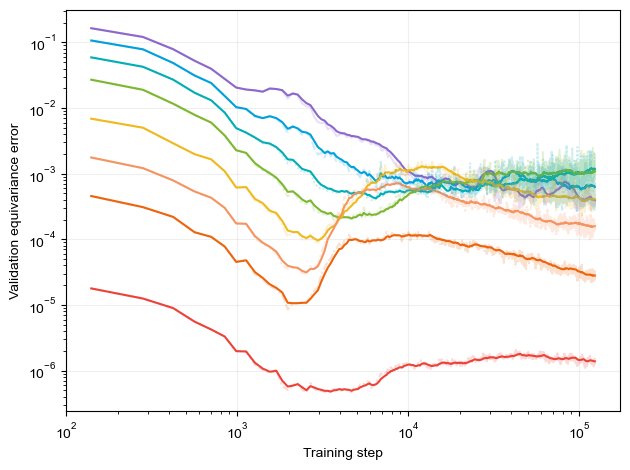

In [18]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

equiv_error_cols = ['_step'] + [col for col in df1.columns if col.startswith('equiv/t=') and col.endswith('/equiv_error')]

plot_df = df1[equiv_error_cols].dropna().reset_index(drop=True).set_index('_step')
plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/equiv_error', ''))
plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['_step'], var_name = 'time', value_name = 'equiv_error')

sns.lineplot(
    data = melted_smoothed_plot_df,
    x = '_step',
    y = 'equiv_error',
    hue = 'time',
    errorbar = None,
    palette=color_palette,
    linestyle='-',
    alpha=1.0,
    legend = False,
)
sns.lineplot(
    data = plot_df,
    errorbar = None,
    palette=color_palette,
    alpha=0.2,
    legend=False,
)

plt.yscale('log')
plt.xscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha = 0.2)

plt.xlabel(f'Training step');
plt.ylabel(f'Validation equivariance error');

# plt.savefig('prot_400M-equiv-error.png', bbox_inches='tight', dpi=300)
# plt.show()
# plt.close()

plot_name = f"prot_400M-equiv-error"

import os
os.makedirs('pdfs', exist_ok=True)

plt.tight_layout()
plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.show()
plt.close()

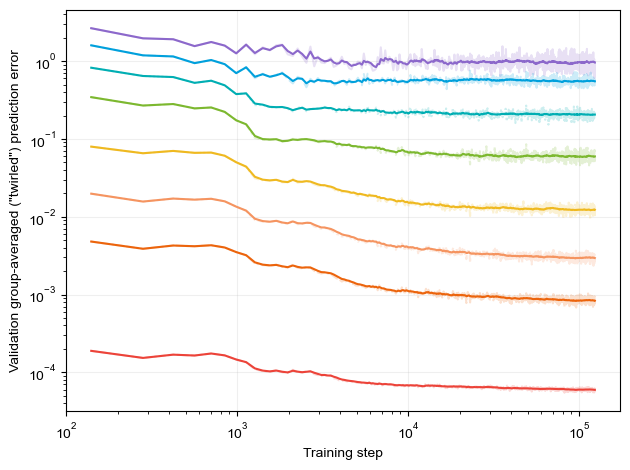

In [27]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

mean_pred_cols = ['_step'] + [col for col in df1.columns if col.startswith('equiv/t=') and col.endswith('/mean_pred_error')]

plot_df = df1[mean_pred_cols].dropna().reset_index(drop=True).set_index('_step')
plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/mean_pred_error', ''))
plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['_step'], var_name = 'time', value_name = 'mean_pred_error')

sns.lineplot(
    data = melted_smoothed_plot_df,
    x = '_step',
    y = 'mean_pred_error',
    hue = 'time',
    errorbar = None,
    palette=color_palette,
    linestyle='-',
    alpha=1.0,
    legend = False,
)
sns.lineplot(
    data = plot_df,
    errorbar = None,
    palette=color_palette,
    alpha=0.2,
    legend=False,
)

plt.yscale('log')
plt.xscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha = 0.2)

plt.xlabel(f'Training step');
plt.ylabel(f'Validation group-averaged ("twirled") prediction error');

# plt.savefig('prot_400M-mean-pred-error.png', bbox_inches='tight', dpi=300)
# plt.show()
# plt.close()

plot_name = f"prot_400M-mean-pred-error"

import os
os.makedirs('pdfs', exist_ok=True)

plt.tight_layout()
plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.show()
plt.close()